In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics

In [2]:
total = pd.read_csv('train.csv')
#total['CentralAir'] = total['CentralAir'].map({'Y': True, 'N': False})

print(total['CentralAir'])

0       Y
1       Y
2       Y
3       Y
4       Y
       ..
1455    Y
1456    Y
1457    Y
1458    Y
1459    Y
Name: CentralAir, Length: 1460, dtype: object


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Split the Dataset into Train and Test
saleprice = pd.DataFrame(total['SalePrice'])   # Predictor
centralair = pd.DataFrame(total['CentralAir'])   # Response
x_train, x_test, y_train, y_test = train_test_split(saleprice, centralair , test_size = 0.25, shuffle=True)

# 1a)

In [4]:
# Import Decision Tree Classifier model from Scikit-Learn
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix

In [5]:
# Create 1st Decision Tree Classifier object
dectree1 = DecisionTreeClassifier(max_depth = 3)
dectree1.fit(x_train, y_train) # train the decision tree model

# Predict SalePrice values corresponding to Total using dectree1
y_train_pred1 = dectree1.predict(x_train)
y_test_pred1 = dectree1.predict(x_test)

# Create 2nd Decision Tree Classifier object
dectree2 = DecisionTreeClassifier(max_depth = 4)
dectree2.fit(x_train, y_train) # train the decision tree model

# Predict SalePrice values corresponding to Total using dectree2
y_train_pred2 = dectree2.predict(x_train)
y_test_pred2 = dectree2.predict(x_test)

[Text(0.5, 0.875, 'SalePrice <= 107750.0\ngini = 0.112\nsamples = 1095\nvalue = [65, 1030]'),
 Text(0.25, 0.625, 'SalePrice <= 61691.5\ngini = 0.469\nsamples = 112\nvalue = [42, 70]'),
 Text(0.125, 0.375, 'SalePrice <= 43655.5\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.0625, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.1875, 0.125, 'gini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.375, 0.375, 'SalePrice <= 79250.0\ngini = 0.444\nsamples = 102\nvalue = [34, 68]'),
 Text(0.3125, 0.125, 'gini = 0.5\nsamples = 14\nvalue = [7, 7]'),
 Text(0.4375, 0.125, 'gini = 0.425\nsamples = 88\nvalue = [27, 61]'),
 Text(0.75, 0.625, 'SalePrice <= 145125.0\ngini = 0.046\nsamples = 983\nvalue = [23, 960]'),
 Text(0.625, 0.375, 'SalePrice <= 144950.0\ngini = 0.115\nsamples = 310\nvalue = [19, 291]'),
 Text(0.5625, 0.125, 'gini = 0.107\nsamples = 301\nvalue = [17, 284]'),
 Text(0.6875, 0.125, 'gini = 0.346\nsamples = 9\nvalue = [2, 7]'),
 Text(0.875, 0.375, 'SalePrice <= 214250.

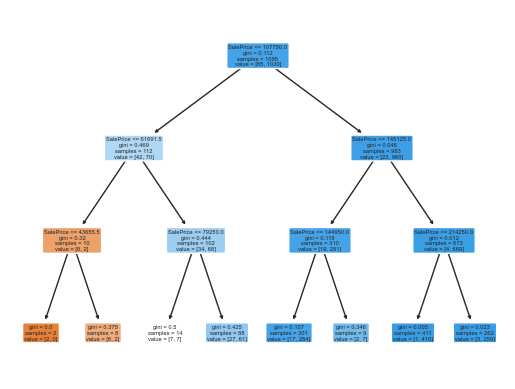

In [6]:
# Plot the trained Decision Tree 1
plot_tree(dectree1, filled=True, rounded=True, 
          feature_names=["SalePrice"], 
          )

[Text(0.48, 0.9, 'SalePrice <= 107750.0\ngini = 0.112\nsamples = 1095\nvalue = [65, 1030]'),
 Text(0.22, 0.7, 'SalePrice <= 61691.5\ngini = 0.469\nsamples = 112\nvalue = [42, 70]'),
 Text(0.08, 0.5, 'SalePrice <= 43655.5\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.04, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.12, 0.3, 'SalePrice <= 52250.0\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.08, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.16, 0.1, 'gini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.36, 0.5, 'SalePrice <= 79250.0\ngini = 0.444\nsamples = 102\nvalue = [34, 68]'),
 Text(0.28, 0.3, 'SalePrice <= 75750.0\ngini = 0.5\nsamples = 14\nvalue = [7, 7]'),
 Text(0.24, 0.1, 'gini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.32, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.44, 0.3, 'SalePrice <= 105950.0\ngini = 0.425\nsamples = 88\nvalue = [27, 61]'),
 Text(0.4, 0.1, 'gini = 0.41\nsamples = 80\nvalue = [23, 57]'),
 Text(0.48, 0

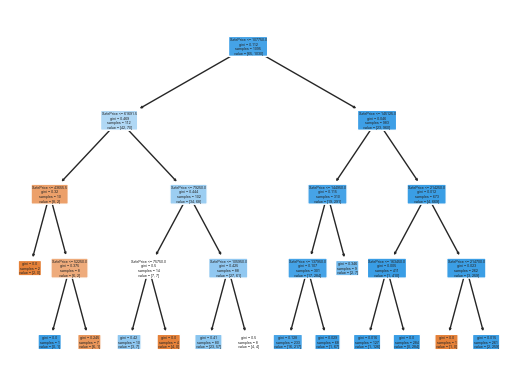

In [7]:
# Plot the trained Decision Tree 2
plot_tree(dectree2, filled=True, rounded=True, 
          feature_names=["SalePrice"], 
          )

# 1b)

Depth 3 Train Set:
TPR =  0.9912621359223301
FPR =  0.7692307692307693
Classification Accuracy for depth = 3 	: 0.9461187214611873


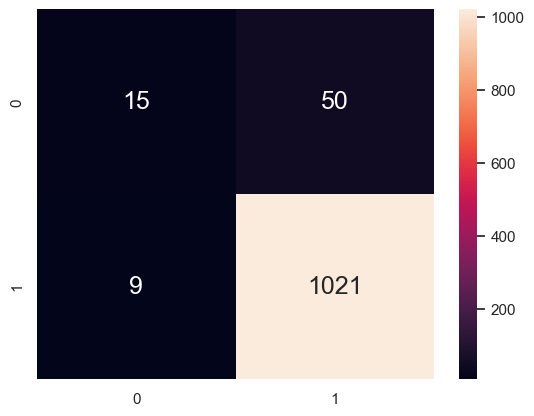

In [8]:
# Plot the two-way Confusion Matrix for Train
sb.heatmap(confusion_matrix(y_train, y_train_pred1), 
           annot = True, fmt=".0f", annot_kws={"size": 18})
cm = confusion_matrix(y_train, y_train_pred1)
TP = cm[1,1]
FP = cm[0,1]
TN = cm[0,0]
FN = cm[1,0]

# Calculate TPR
TPR = TP / (TP + FN)

# Calculate FNR
FPR = FP / (FP + TN)

print("Depth 3 Train Set:")
print("TPR = ", TPR)
print("FPR = ", FPR)

# Print the Classification Accuracy
print("Classification Accuracy for depth = 3 \t:", dectree1.score(x_train, y_train))

Depth 3 Test Set:
TPR =  0.9940298507462687
FPR =  0.8
Classification Accuracy for depth = 3 	: 0.9287671232876712


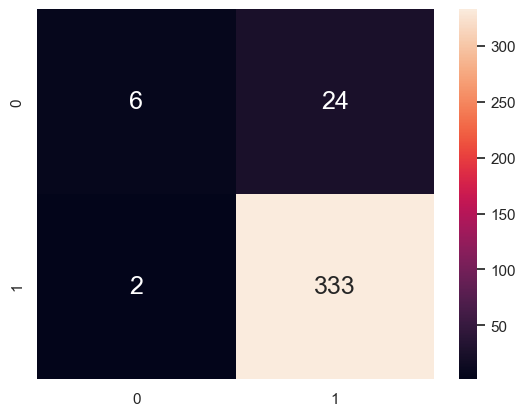

In [9]:
# Plot the two-way Confusion Matrix for Test
sb.heatmap(confusion_matrix(y_test, y_test_pred1), 
           annot = True, fmt=".0f", annot_kws={"size": 18})
cm = confusion_matrix(y_test, y_test_pred1)
TP = cm[1,1]
FP = cm[0,1]
TN = cm[0,0]
FN = cm[1,0]

# Calculate TPR
TPR = TP / (TP + FN)

# Calculate FNR
FPR = FP / (FP + TN)

print("Depth 3 Test Set:")
print("TPR = ", TPR)
print("FPR = ", FPR)

# Print the Classification Accuracy
print("Classification Accuracy for depth = 3 \t:", dectree1.score(x_test, y_test))

Depth 4 Train Set:
TPR =  0.9951456310679612
FPR =  0.7384615384615385
Classification Accuracy for depth = 4 	: 0.9515981735159817


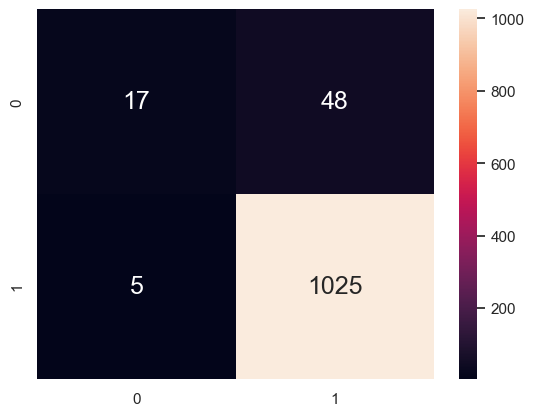

In [10]:
# Plot the two-way Confusion Matrix for Train
sb.heatmap(confusion_matrix(y_train, y_train_pred2), 
           annot = True, fmt=".0f", annot_kws={"size": 18})
cm = confusion_matrix(y_train, y_train_pred2)
TP = cm[1,1]
FP = cm[0,1]
TN = cm[0,0]
FN = cm[1,0]

# Calculate TPR
TPR = TP / (TP + FN)

# Calculate FNR
FPR = FP / (FP + TN)

print("Depth 4 Train Set:")
print("TPR = ", TPR)
print("FPR = ", FPR)

# Print the Classification Accuracy
print("Classification Accuracy for depth = 4 \t:", dectree2.score(x_train, y_train))

Depth 4 Test Set:
TPR =  0.9850746268656716
FPR =  0.7666666666666667
Classification Accuracy for depth = 4 	: 0.9232876712328767


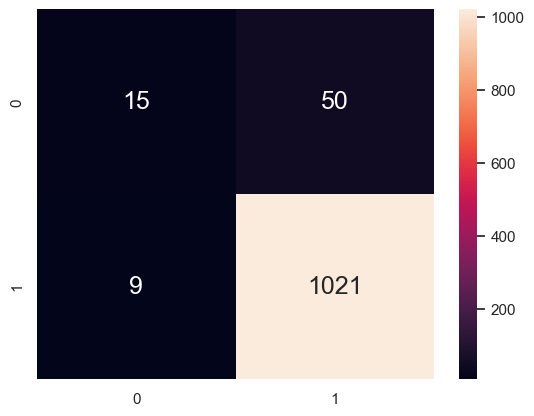

In [11]:
# Plot the two-way Confusion Matrix for Test
sb.heatmap(confusion_matrix(y_train, y_train_pred1), 
           annot = True, fmt=".0f", annot_kws={"size": 18})
cm = confusion_matrix(y_test, y_test_pred2)
TP = cm[1,1]
FP = cm[0,1]
TN = cm[0,0]
FN = cm[1,0]

# Calculate TPR
TPR = TP / (TP + FN)

# Calculate FNR
FPR = FP / (FP + TN)

print("Depth 4 Test Set:")
print("TPR = ", TPR)
print("FPR = ", FPR)

# Print the Classification Accuracy
print("Classification Accuracy for depth = 4 \t:", dectree2.score(x_test, y_test))

# 1b) Model of depth=3 is better. In the test set, the value for the classification accuracy is higher as compared to the value obtained when using the model of depth = 4, which means that when using the model of depth 3, the fraction of correct predictions made is higher.

# 2)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

overallqual = pd.DataFrame(total['OverallQual'])   # Predictor
yearbuilt = pd.DataFrame(total['YearBuilt'])   # Predictor
centralair = pd.DataFrame(total['CentralAir'])   # Response

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9461187214611873

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.9205479452054794

Depth 3 Train Set:
TPR =  0.9941747572815534
FPR =  0.8153846153846154
 
Depth 3 Test Set:
TPR =  0.991044776119403
FPR =  0.8666666666666667


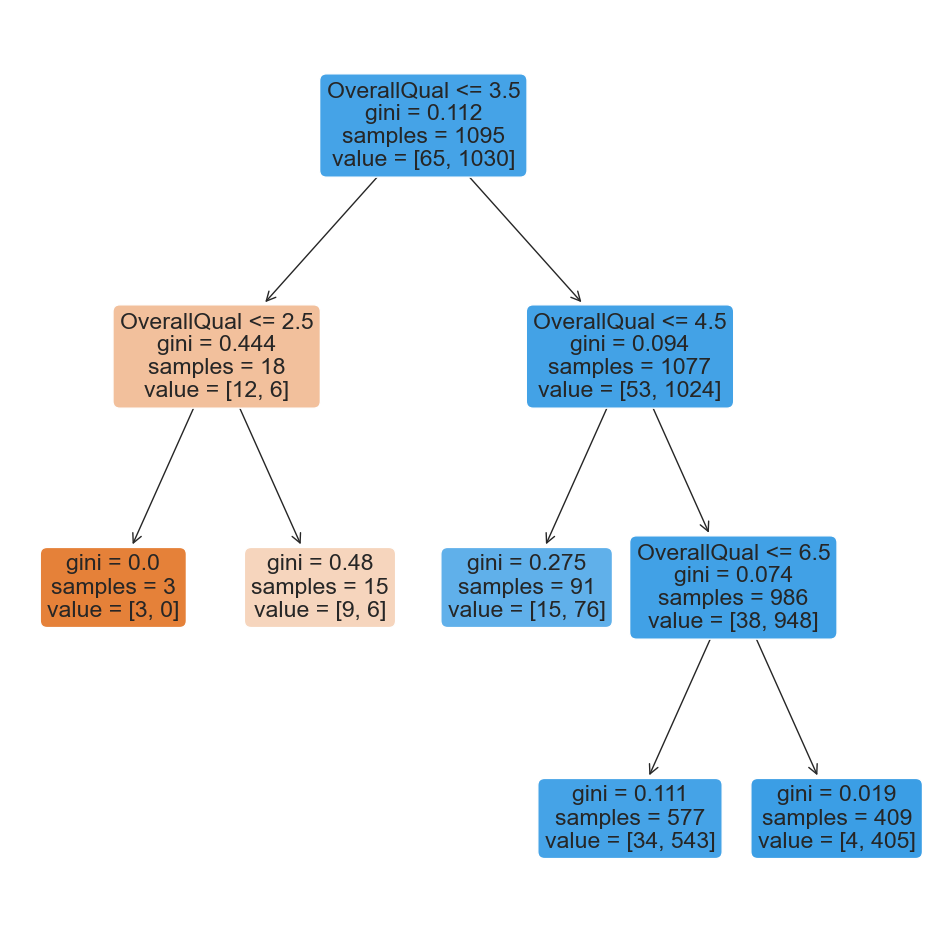

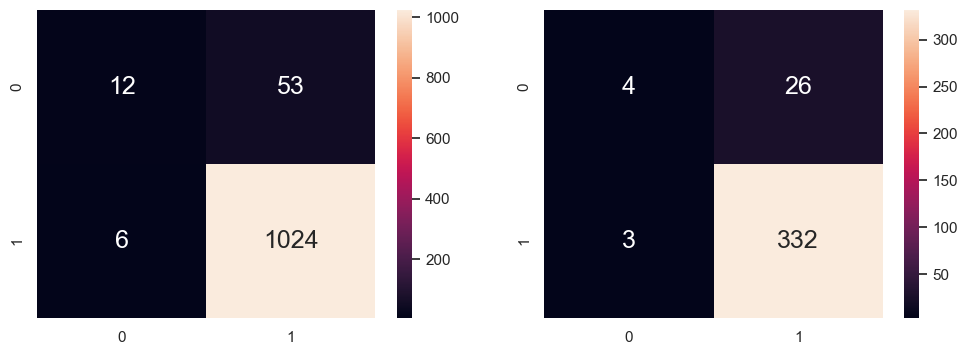

In [29]:
# Split the Dataset into Train and Test
x_train, x_test, y_train, y_test = train_test_split(overallqual, centralair , test_size = 0.25, shuffle=True, random_state=104)
dectree = DecisionTreeClassifier(max_depth = 3)
dectree.fit(x_train, y_train)                    # train the decision tree model


# Plot the trained Decision Tree
from sklearn.tree import plot_tree

f = plt.figure(figsize=(12,12))
plot_tree(dectree, filled=True, rounded=True, 
          feature_names=["OverallQual"], 
          )

# Predict centralair corresponding to overallqual
y_train_pred = dectree.predict(x_train)
y_test_pred = dectree.predict(x_test)


# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(x_train, y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(x_test, y_test))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

cm = confusion_matrix(y_train, y_train_pred)
TP = cm[1,1]
FP = cm[0,1]
TN = cm[0,0]
FN = cm[1,0]
# Calculate TPR
TPR = TP / (TP + FN)
# Calculate FNR
FPR = FP / (FP + TN)

print("Depth 3 Train Set:")
print("TPR = ", TPR)
print("FPR = ", FPR)
print(" ")


cm = confusion_matrix(y_test, y_test_pred)
TP = cm[1,1]
FP = cm[0,1]
TN = cm[0,0]
FN = cm[1,0]
# Calculate TPR
TPR = TP / (TP + FN)
# Calculate FNR
FPR = FP / (FP + TN)

print("Depth 3 Test Set:")
print("TPR = ", TPR)
print("FPR = ", FPR)

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9424657534246575

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.9095890410958904

Depth 4 Train Set:
TPR =  1.0
FPR =  0.9692307692307692
 
Depth 4 Test Set:
TPR =  0.991044776119403
FPR =  1.0


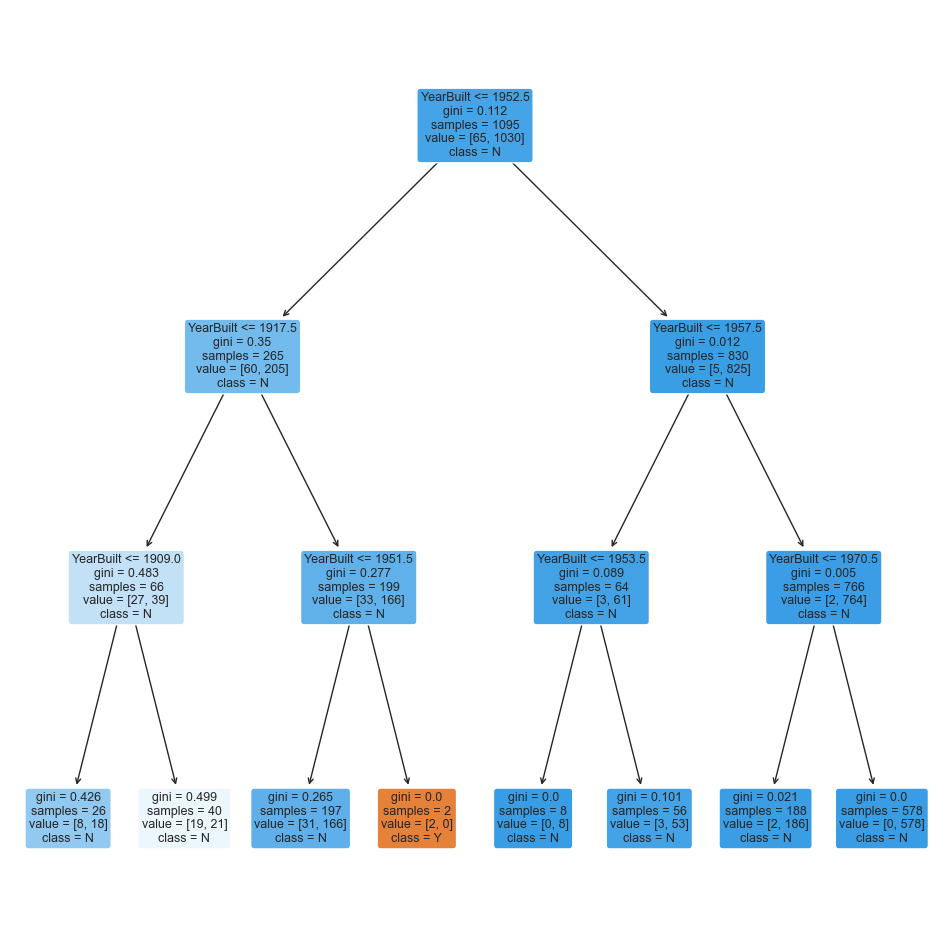

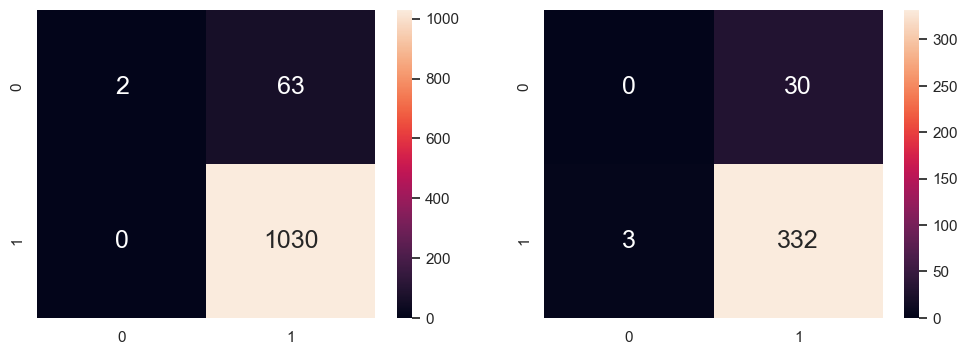

In [14]:
# Split the Dataset into Train and Test
x_train, x_test, y_train, y_test = train_test_split(yearbuilt, centralair , test_size = 0.25, shuffle=True, random_state=104)
dectree = DecisionTreeClassifier(max_depth = 3)
dectree.fit(x_train, y_train)                    # train the decision tree model

# Plot the trained Decision Tree
from sklearn.tree import plot_tree

f = plt.figure(figsize=(12,12))
plot_tree(dectree, filled=True, rounded=True, 
          feature_names=["YearBuilt"], 
          class_names=["Y","N"])

# Predict centralair corresponding to yearbuilt
y_train_pred = dectree.predict(x_train)
y_test_pred = dectree.predict(x_test)


# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(x_train, y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(x_test, y_test))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

cm = confusion_matrix(y_train, y_train_pred)
TP = cm[1,1]
FP = cm[0,1]
TN = cm[0,0]
FN = cm[1,0]
# Calculate TPR
TPR = TP / (TP + FN)
# Calculate FNR
FPR = FP / (FP + TN)

print("Depth 4 Train Set:")
print("TPR = ", TPR)
print("FPR = ", FPR)
print(" ")


cm = confusion_matrix(y_test, y_test_pred)
TP = cm[1,1]
FP = cm[0,1]
TN = cm[0,0]
FN = cm[1,0]
# Calculate TPR
TPR = TP / (TP + FN)
# Calculate FNR
FPR = FP / (FP + TN)

print("Depth 4 Test Set:")
print("TPR = ", TPR)
print("FPR = ", FPR)

# 2) Overall quality. The prediction accuracy of its model on the test set is higher than that of yearbuilt, hence the fraction of correct predictions made by the model of overallqual is higher. However, everytime the test model is run, the values will be different.

# 3) 

[Text(0.5, 0.875, 'SalePrice <= 107700.0\ngini = 0.123\nsamples = 1095\nvalue = [72, 1023]'),
 Text(0.25, 0.625, 'SalePrice <= 61691.5\ngini = 0.465\nsamples = 114\nvalue = [42, 72]'),
 Text(0.125, 0.375, 'SalePrice <= 46000.0\ngini = 0.278\nsamples = 12\nvalue = [10, 2]'),
 Text(0.0625, 0.125, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.1875, 0.125, 'gini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.375, 0.375, 'SalePrice <= 106125.0\ngini = 0.431\nsamples = 102\nvalue = [32, 70]'),
 Text(0.3125, 0.125, 'gini = 0.416\nsamples = 95\nvalue = [28, 67]'),
 Text(0.4375, 0.125, 'gini = 0.49\nsamples = 7\nvalue = [4, 3]'),
 Text(0.75, 0.625, 'SalePrice <= 137950.0\ngini = 0.059\nsamples = 981\nvalue = [30, 951]'),
 Text(0.625, 0.375, 'SalePrice <= 137700.0\ngini = 0.157\nsamples = 244\nvalue = [21, 223]'),
 Text(0.5625, 0.125, 'gini = 0.151\nsamples = 243\nvalue = [20, 223]'),
 Text(0.6875, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.875, 0.375, 'SalePrice <= 145125

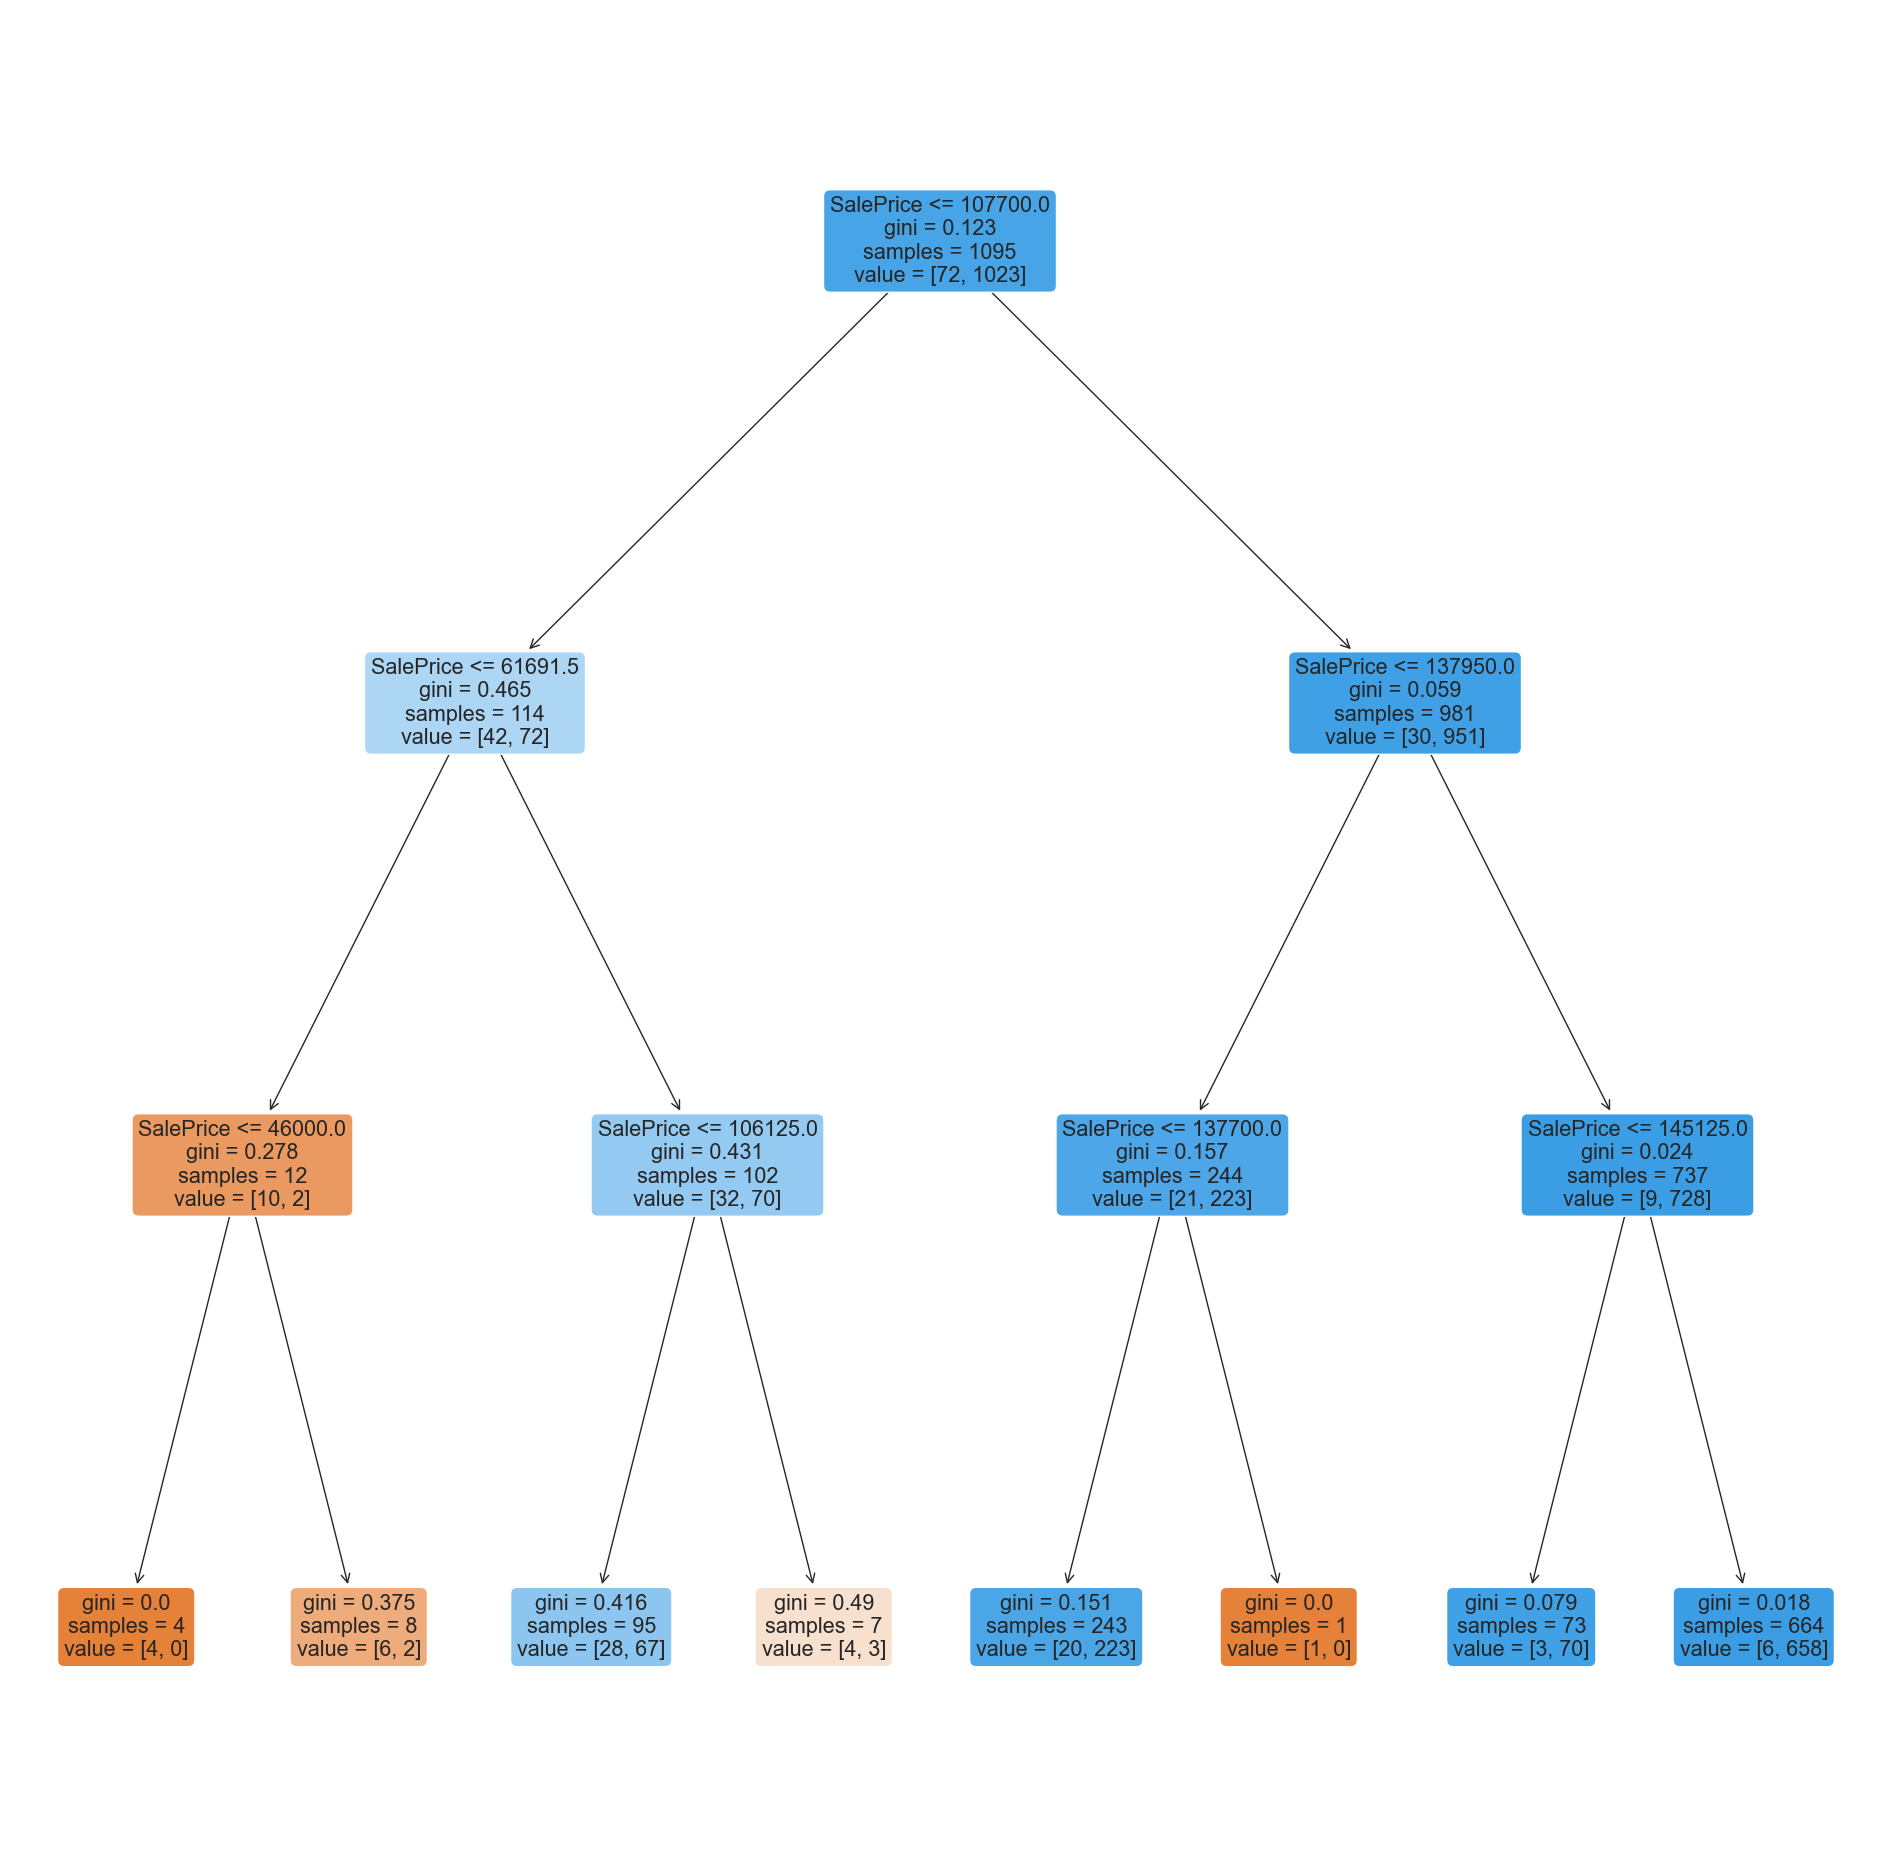

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Split the Dataset into Train and Test
saleprice = pd.DataFrame(total['SalePrice'])   # Predictor
centralair = pd.DataFrame(total['CentralAir'])   # Response
x_train, x_test, y_train, y_test = train_test_split(saleprice, centralair , test_size = 0.25, shuffle=True)

# Create 1st Decision Tree Classifier object
dectree1 = DecisionTreeClassifier(max_depth = 3)
dectree1.fit(x_train, y_train) # train the decision tree model

# Predict SalePrice values corresponding to Total using dectree1
y_train_pred1 = dectree1.predict(x_train)
y_test_pred1 = dectree1.predict(x_test)

# Create 2nd Decision Tree Classifier object
dectree = DecisionTreeClassifier(max_depth = 3)
dectree.fit(x_train, y_train) # train the decision tree model

# Predict SalePrice values corresponding to Total using dectree2
y_train_pred = dectree.predict(x_train)
y_test_pred = dectree.predict(x_test)
# Plot the trained Decision Tree 1
f = plt.figure(figsize=(24,24))
plot_tree(dectree, filled=True, rounded=True, 
          feature_names=["SalePrice"]
          )

In [23]:
new_data = pd.concat([x_train, y_train], axis = 1)
new_data = new_data.query("106125 <= SalePrice <= 107700")
print(new_data)

      SalePrice CentralAir
520      106250          N
74       107400          N
217      107000          N
772      107000          Y
1292     107500          N
1206     107000          Y
535      107500          Y


In [27]:
new_data = new_data.query("CentralAir == 'N'")
print(new_data)

      SalePrice CentralAir
520      106250          N
74       107400          N
217      107000          N
1292     107500          N
